# Constrained Cobb-Douglas with Model-Predictive Control (MPC) Discipline

The previous live intraday Cobb-Douglas (CD) engine that ran from 2026-05-05 to 2026-05-15 on a paper account was discontinued at market close on 2026-05-18 with mixed results (flat after cost). The allocator solved the unconstrained CD utility maximization problem at a 30-min cadence, with turnover and drawdown gates along with automatic and queued (human intervention) order flow. However, jitter of the user preference parameters $\gamma_{i}$ drove many small orders and we incurred high news application programming interface (API) charges without providing any obvious benefit, which led us to shut down the experiment.

This notebook walks through an updated design that replaces the original formulation: we still use an optimal **constrained Cobb-Douglas allocator** subject to a budget constraint, however, now we consider _three additional constraints_:
* __Risk Constraint__: First, we add a **covariance (risk) budget** constraint that limits the risk of the allocation. This will allow us to control the risk of the allocation and prevent it from taking on too much risk in pursuit of higher growth rates. This is a natural extension to the original formulation, which only considered the growth rate of the portfolio without any explicit consideration of risk. By adding a covariance budget constraint, we can ensure that the allocation does not take on excessive risk in pursuit of higher growth rates.
* __Turnover Constraint__: Second, we add a **turnover budget** constraint that limits the amount of trading. This will guard against large changes in the allocation that may be driven by noise in the user preference parameters $\gamma_{i}$. Again, this is user configurable and can be adjusted depending on the desired level of trading activity. 
* __Concentration Constraint__: Third, we add a **concentration budget** constraint that limits the maximum weight of any single asset. This is also configurable and can be adjusted depending on the desired level of diversification. By adding a concentration constraint, we can ensure that the allocation does not become too concentrated in any single asset.
 
Next, we wrap the allocation and constraints in a **model-predictive control (MPC)** discipline that forward-projects the allocation and fires a rebalancing event when the realized path leaves a model-projected confidence band, i.e., when the market has deviated significantly from the expected path of our model simulation, or we hit a specified rebalancing time trigger, i.e., we re-evaluate the portfolio every $T$ days. 

Finally, we benchmark the proposed design against five baselines on a hold-out window from 2025-2026 with after-cost, but pre-tax accounting. The universe is a $K$-ticker basket generated using the S4 per-sector bandit (uniform $q_{s}$-per-sector GICS quotas).

> **Learning Objectives:**
>
> By the end of this section, you should be able to:
> 
> * __Constrained allocation as a convex program:__ State the budget, covariance, turnover, and concentration constraints that wrap the Cobb-Douglas objective. Recognize that the resulting program is convex and solves in milliseconds at production basket sizes.
> * __Event-driven rebalancing:__ Define the MPC in-spec band and the three trigger conditions that decide when re-allocation fires. Explain why event-driven cadence replaces the live engine's information-free clock.
> * __Pairwise strategy comparison:__ Read the six-strategy bake-off and identify which row pairs isolate the cadence effect, the constraint effect, and the combined fix. Interpret a surprising or unexpected ranking against the design intent.

Let's walk through the theory and read the bake-off. Exciting!

___

## Theory: Constrained Cobb-Douglas Allocation with MPC Discipline

In this section, we take a look at the updated constrained Cobb-Douglas formulation and the model predictive control (MPC) trigger conditions. Let's start with the reformulated Cobb-Douglas allocation problem, then we'll examine the three trigger conditions that define the MPC discipline.

> **Constrained Cobb-Douglas (CD) Optimization**
>
> The idea behind the updated constrained Cobb-Douglas formulation is to wrap the classic Cobb-Douglas objective in constraints that are interpretable in client terms: a budget constraint, a covariance (risk) constraint, a turnover constraint, and a concentration constraint. 
> 
> Given a basket of $K$ tickers, share prices $\mathbf{p} \in \mathbb{R}^K_{>0}$, investment budget $B$, prior shares $\mathbf{n}_{\text{prev}} \in \mathbb{R}^K_{>0}$, single index model (SIM)-implied covariance $\boldsymbol{\Sigma}\in \mathbb{R}^{K \times K}$, and average transaction cost per share traded $\bar{c}\in \mathbb{R}_{>0}$ (commission + half-spread + slippage), we estimate the number of new shares $\mathbf{n}_{\tau}$ to buy at time $\tau$ that maximizes the investor utility under the (log) Cobb-Douglas formulation:
>
> $$\max_{n_i > 0} \; \sum_{i=1}^{K} \gamma_i \log(n_i)$$
>
> subject to the constraints:
>
> $$
\underbrace{\sum_i n_i p_i \le B}_{\text{budget}}, \quad \underbrace{\mathbf{w}^\top \boldsymbol{\Sigma} \mathbf{w} \le \sigma_{\max}^2}_{\text{risk}}, \quad \underbrace{\bar{c}\,\|\mathbf{n} - \mathbf{n}_{\text{prev}}\|_1\le K_{\text{turnover}}}_{\text{turnover}}, \quad \underbrace{w_i \le w_{\max}}_{\text{concentration}}, \quad \underbrace{n_i > 0}_{\text{positivity}}
> $$
>
> where $w_i = n_i p_i / B$, $K_{\text{turnover}}$ denotes the turnover budget, and $\|\star\|_1$ is the L1 norm. Strict positivity ($n_i > 0$) is required for the log objective to be finite; the solver enforces it numerically as $n_i \ge \varepsilon$ with $\varepsilon = 10^{-8}$, and pins non-preferred names ($\gamma_i \le 0$) at $\varepsilon = 10^{-3}$ shares before optimizing over the preferred subset. 
> 
> __Design variables__: The two design knobs we can tune are the risk budget $\sigma_{\max}$ (annualized portfolio vol cap) and $K_{\text{turnover}}$ (dollar turnover budget per decision). The preference vector $\boldsymbol{\gamma}$ has scalar entries $\gamma_i$ computed from single index model regression parameters and the regime-lens $\lambda$ (no news term in this implementation). 
> 
> Finally, the covariance is the single index model decomposition $\boldsymbol{\Sigma} = \sigma_m^2 \boldsymbol{\beta}\boldsymbol{\beta}^\top + \mathrm{diag}(\sigma_{\varepsilon,i}^2)$, built from the same parameters that drive the investor-preference vector $\boldsymbol{\gamma}$.

The optimization problem above specifies (optimally) *what* to hold at a decision time. However, it does not specify *when* a decision time occurs. Toward this question, we specify a __trigger condition__ on the forward-projected portfolio value that decides when to fire the allocator. Between trigger events, the engine submits no orders and holds the current position.

> **Model predictive control (MPC) trigger conditions**
>
> Let $t$ be the most recent allocation time and the index $\tau \in \{t+1, t+2, \ldots, t+T\}$ represent future trading days, where $T$ is the forward-projection horizon. We distinguish two portfolio-value sequences indexed by $\tau$: the **realized** value $V_\tau$, a single observed number per day from marking the held position to market, and the **simulated** values $V_\tau^{(j)}$ for $j = 1, \ldots, N$ Monte Carlo scenario paths used to build the confidence band. We forward-project the $N$ simulated paths by holding the current allocation fixed and drawing market log-growth rates from [our generative growth rate model](https://arxiv.org/abs/2603.10202). 
> 
> On path $j \in \{1, \ldots, N\}$, the per-asset log-growth rate is given by the single index model (SIM) equation:
> $$g_{i,\tau}^{(j)} = \alpha_i + \beta_i\, g_{m,\tau}^{(j)} + \varepsilon_{i,\tau}^{(j)},$$
>
> where:
>
> * $g_{i,\tau}^{(j)}$ is the log-growth rate of asset $i$ on day $\tau$ under scenario $j$;
> * $\alpha_i$ and $\beta_i$ are the SIM intercept and market-loading (sensitivity to the market) for asset $i$ at the current decision time, initialized from training-window OLS and maintained online via exponentially-weighted least squares (EWLS) as new returns arrive during the hold-out;
> * $g_{m,\tau}^{(j)}$ is the market (SPY) log-growth rate on day $\tau$ under scenario $j$, drawn from [the generative growth rate model](https://arxiv.org/abs/2603.10202)
> * $\varepsilon_{i,\tau}^{(j)} \sim \mathcal{N}(0, \sigma_{\varepsilon,i}^2)$ is the asset-$i$ idiosyncratic shock on day $\tau$ under scenario $j$, independent across $i$, $\tau$, and $j$, with idiosyncratic variance $\sigma_{\varepsilon,i}^2$ from the same EWLS-maintained single index model state.
>
> Compounding the per-asset growth rates against the held weights produces $N$ portfolio wealth paths $V_\tau^{(j)}$ at each future day. Let
>
> $$\mu_\tau = \frac{1}{N}\sum_{j=1}^{N} V_\tau^{(j)}, \quad \sigma_\tau^2 = \frac{1}{N}\sum_{j=1}^{N} \bigl(V_\tau^{(j)} - \mu_\tau\bigr)^2$$
>
> be the ensemble mean and variance across the $N$ paths at day $\tau$. The realized portfolio path is **in-spec** at day $\tau$ iff:
>
> $$\mu_\tau - z\,\sigma_\tau \;\le\; V_\tau \;\le\; \mu_\tau + z\,\sigma_\tau,$$
>
> where $z$ is the band z-score that sets the width of the confidence band (default $z = 1.96$ corresponds to a 95% band). With defaults $T = 21$ trading days and $N = 1000$ paths, re-allocation fires when **any** of the following hold:
>
> 1. The realized portfolio value $V_\tau$ exits the in-spec band from the simulated paths. This means the agent observes a significant deviation from the expected path of the model simulation, which could indicate that the market conditions have changed and the current allocation may no longer be optimal.
> 2. $T$ trading days have elapsed since the last allocation at $t_{\text{last}}$, i.e., $\tau - t_{\text{last}} \ge T$ (forced refresh).
> 3. The realized drawdown from peak exceeds $D_{\max}$: i.e., $V_\tau / V^{\text{peak}} \le 1 - D_{\max}$, where $V^{\text{peak}} = \max_{s \le \tau} V_s$ is the running maximum of realized portfolio value since the start of the run and $D_{\max}$ is the drawdown circuit-breaker threshold (default $D_{\max} = 8\%$).
>
> Between triggers the engine submits no orders. This is the discipline that fixes the live failure mode.

These ideas can be implemented in the following algorithm, which describes the full constrained CD with MPC discipline that runs on the hold-out window.

#### Algorithm: Constrained CD with MPC (Hold-Out Deployment Loop)

__Initialize__: Given the following inputs:

- __Universe__: the frozen $K$-ticker basket $\mathcal{B}$, the hold-out window $\mathcal{T}_{\text{hold}}$ (the ordered set of trading days over which the engine runs), the per-share price vector $\mathbf{p}_\tau \in \mathbb{R}^K_{>0}$ at each decision day $\tau \in \mathcal{T}_{\text{hold}}$, and the running portfolio budget $B_\tau$ (current wealth).
- __Allocator constraints__: $\sigma_{\max}$, the annualized portfolio volatility cap (in growth-rate-vol units); $K_{\text{turnover}}$, the dollar turnover budget per decision; $w_{\max}$, the per-name concentration cap (maximum weight any single ticker may hold); $\bar{c}$, the average transaction cost per share traded.
- __MPC parameters__: $T$, the forward-projection horizon (trading days); $N$, the number of forward-projection Monte Carlo paths; $z$, the band z-score that sets the width of the confidence band ($z = 1.96$ corresponds to a 95% band); $D_{\max}$, the drawdown circuit-breaker threshold (fraction of peak wealth).
- __Online SIM state__: a per-ticker exponential weighted least squares (EWLS) state $\mathcal{S}_i$ for $i = 1, \ldots, K$, initialized from training-window OLS estimates $(\alpha_i^0, \beta_i^0, \sigma_{\varepsilon,i}^0)$ with half-life $h$ (default $h = 252$ trading days; the corresponding decay factor is $\eta = 2^{-1/h}$). At each day $\tau$, $\mathcal{S}_i$ yields the current parameter estimate $(\alpha_{i,\tau}, \beta_{i,\tau}, \sigma_{\varepsilon,i,\tau})$ and is updated after each day's realized returns are observed.

Set the initial position $\mathbf{n}_{\text{prev}} \gets \mathbf{0}$ (all cash), the starting wealth $V_{\tau_0} \gets B_0$, the peak wealth $V^{\text{peak}} \gets B_0$, and the last-allocation time $t_{\text{last}} \gets -\infty$ (so the $T$-day refresh trigger fires on iteration 1). 

On the first iteration the turnover constraint is relaxed (set $K_{\text{turnover}} \gets B_0$), since moving from all cash to any non-trivial allocation would otherwise exceed the per-decision budget.

For each trading day $\tau\in \mathcal{T}_{\text{hold}}$ __do__:

1. Read the current single index model parameters $(\alpha_{i,\tau}, \beta_{i,\tau}, \sigma_{\varepsilon,i,\tau})$ for each ticker from its exponential weighted least squares (EWLS) state $\mathcal{S}_i$. Mark the portfolio to market:
   - if $\mathbf{n}_{\text{prev}} = \mathbf{0}$, set $V_\tau = B_0$ and $\mathbf{w}_\tau^{\text{held}} = \mathbf{0}$ (all cash);
   - otherwise if $\mathbf{n}_{\text{prev}} \neq \mathbf{0}$, compute $V_\tau = \sum_i n_{i,\text{prev}}\, p_{i,\tau}$ and $w_{i,\tau}^{\text{held}} = n_{i,\text{prev}}\, p_{i,\tau} / V_\tau$, the weights we currently hold (distinct from the optimal $\mathbf{w}_\tau^\star$ computed only in step 4 when a trigger fires).
2. Forward-project $N$ scenario paths $V_\tau^{(j)}$ over $[\tau, \tau + T]$ by sampling market log-growth rates from the market factor generative model, generating per-asset rates via a single-index model extension, and compounding against $\mathbf{w}_\tau^{\text{held}}$. Form the in-spec band $[\mu_\tau - z\sigma_\tau,\; \mu_\tau + z\sigma_\tau]$ from the ensemble mean and standard deviation of the $N$ paths. (On iteration 1, $\mathbf{w}_\tau^{\text{held}} = \mathbf{0}$, so the band collapses to $\{B_0\}$ and trigger condition (2) fires the first allocation.)
3. Update the running peak wealth $V^{\text{peak}} \gets \max(V^{\text{peak}}, V_\tau)$, then check the three trigger conditions on the realized portfolio.
4. If any trigger fires, build the day's covariance $\boldsymbol{\Sigma}_\tau = \sigma_m^2 \boldsymbol{\beta}_\tau \boldsymbol{\beta}_\tau^\top + \mathrm{diag}(\sigma_{\varepsilon,i,\tau}^2)$ and the preference vector $\boldsymbol{\gamma}_\tau$ from the current single-index model parameters, the EMA-based regime-lens $\lambda_\tau$, and the smoothed market growth $g_{m,\tau}$. 
   - Solve the constrained CD problem under $(\boldsymbol{\gamma}_\tau, \boldsymbol{\Sigma}_\tau)$ for the optimal weights $\mathbf{w}_\tau^\star$, translate to integer shares $\mathbf{n}_\tau$, apply the cost and tax models, then update $\mathbf{n}_{\text{prev}} \gets \mathbf{n}_\tau$, set $t_{\text{last}} \gets \tau$, and record the trigger reason. Otherwise, hold the current position and submit no orders.
5. Observe the day's realized log-growth rates $g_{i,\tau}$ (per ticker) and $g_{m,\tau}$ (market), and update each EWLS state $\mathcal{S}_i$ with $(g_{i,\tau}, g_{m,\tau})$ under decay factor $\eta$, yielding refreshed parameters $(\alpha_{i,\tau+1}, \beta_{i,\tau+1}, \sigma_{\varepsilon,i,\tau+1})$ for day $\tau+1$.

__Output__: Wealth path $\{V_\tau\}_{\tau \in \mathcal{T}_{\text{hold}}}$, trigger log, after-cost after-tax summary.

___

### Baseline Strategies for Comparison
The bake-off below compares the constrained Cobb-Douglas allocator with MPC discipline against five baselines on the same frozen $K$-ticker basket $\mathcal{B}$, the same hold-out window $\mathcal{T}_{\text{hold}}$, the same starting budget $B_0$, and the same after-cost / after-tax execution engine. The five baselines span the design dimensions that matter for the comparison: classical buy-and-hold (EqualWeight, MinVar), the live engine's existing allocator at a sane daily cadence (UnconstrainedCD), the standard-finance mean-variance alternative (CostAwareMV), and a trigger-only variant that keeps the closed-form Cobb-Douglas allocator but wraps it in the MPC discipline (CDWithMPC). Each baseline is described in turn below.

#### EqualWeight (buy-and-hold)
The simplest possible allocator and the "no information, no trading" floor that any active strategy must beat after costs. EqualWeight buys an equal-dollar slice of each ticker in the basket on day 1 and holds. It uses neither the preference vector $\boldsymbol{\gamma}$ nor the covariance $\boldsymbol{\Sigma}$, and submits no further trades after the bootstrap.

> **EqualWeight allocation:**
>
> On day 1 of the hold-out window, given the starting budget $B_0$ and the day-1 share price vector $\mathbf{p}_1 \in \mathbb{R}^K_{>0}$, set the target share count per ticker to
>
> $$n_i = \frac{w_i\, B_0}{p_{i,1}}, \quad w_i = \frac{1}{K}, \quad i = 1, \ldots, K.$$
>
> Hold the resulting share vector $\mathbf{n}$ for the entire hold-out window. No further allocator decisions fire on days $\tau > 1$, so all subsequent transaction costs are zero and the only return-generating mechanism is buy-and-hold drift in the underlying prices.

#### MinVar (buy-and-hold)
The classical long-only minimum-variance portfolio, and the S1 reference allocator from the lecture series. MinVar uses only the covariance $\boldsymbol{\Sigma}$ and ignores the preference vector $\boldsymbol{\gamma}$ entirely. It is the "risk-only, no view" buy-and-hold baseline.

> **MinVar allocation:**
>
> On day 1 of the hold-out window, given the day-1 SIM covariance $\boldsymbol{\Sigma}_1 = \sigma_m^2 \boldsymbol{\beta}_1 \boldsymbol{\beta}_1^\top + \mathrm{diag}(\sigma_{\varepsilon,i,1}^2)$ from the EWLS-maintained SIM state (which on day 1 equals the training-window OLS calibration, since no hold-out observations have yet been absorbed), solve
>
> $$\min_{\mathbf{w}} \; \mathbf{w}^\top \boldsymbol{\Sigma}_1 \mathbf{w} \quad \text{s.t.} \quad \sum_i w_i = 1, \; 0 \le w_i \le 1$$
>
> for the long-only minimum-variance weights $\mathbf{w}^\star$. Translate to target shares $n_i = w_i^\star B_0 / p_{i,1}$ and hold for the full hold-out window. As with EqualWeight, no further allocator decisions fire on days $\tau > 1$.

#### UnconstrainedCD (daily)
The closed-form Cobb-Douglas allocator at a daily rebalance cadence. UnconstrainedCD is the existing live-engine allocator (the one that produced the flat-with-bleed P&L on the 30-min clock), here moved to once-a-day rebalancing and stripped of every constraint except a per-name positivity floor. It is the "view-only, no risk control, no cadence control" reference point that ConstrainedCDWithMPC is trying to improve on.

> **Unconstrained Cobb-Douglas allocation:**
>
> At each trading day $\tau \in \mathcal{T}_{\text{hold}}$, given the current preference vector $\boldsymbol{\gamma}_\tau$, the day-$\tau$ price vector $\mathbf{p}_\tau$, and the running portfolio budget $B_\tau$ (current wealth), partition the basket into preferred names $\mathcal{P}_\tau = \{i : \gamma_{i,\tau} > 0\}$ and non-preferred names $\mathcal{N}_\tau = \{i : \gamma_{i,\tau} \le 0\}$. Pin every non-preferred name at $n_{i,\tau} = \varepsilon = 10^{-3}$ shares and compute the effective budget $B_\tau^{\text{eff}} = B_\tau - \varepsilon \sum_{j \in \mathcal{N}_\tau} p_{j,\tau}$ available for the preferred subset. Compute target shares for preferred names from the closed-form solution
>
> $$n_{i,\tau} = \frac{\gamma_{i,\tau}}{\sum_{j \in \mathcal{P}_\tau} \gamma_{j,\tau}} \cdot \frac{B_\tau^{\text{eff}}}{p_{i,\tau}}, \quad i \in \mathcal{P}_\tau.$$
>
> The allocator fires every trading day in $\mathcal{T}_{\text{hold}}$ without any covariance, turnover, or concentration constraint, so daily turnover is bounded only by the closed-form weights' day-over-day variation in $\boldsymbol{\gamma}_\tau$.

#### CostAwareMV (daily)
The standard-finance alternative to constrained Cobb-Douglas: a one-step mean-variance program with a linear turnover penalty, at daily cadence. CostAwareMV consumes the same inputs as ConstrainedCDWithMPC ($\boldsymbol{\gamma}_\tau$, $\boldsymbol{\Sigma}_\tau$, held weights), but replaces the Cobb-Douglas objective with mean-variance and replaces the hard turnover cap with a soft L1 penalty. This is the "what would a textbook quant do" baseline.

> **Cost-aware mean-variance allocation:**
>
> At each trading day $\tau \in \mathcal{T}_{\text{hold}}$, given the current preference vector $\boldsymbol{\gamma}_\tau$, the EWLS-maintained covariance $\boldsymbol{\Sigma}_\tau$, the day-$\tau$ price vector $\mathbf{p}_\tau$, and the held weight vector $\mathbf{w}_\tau^{\text{held}}$ with components $w_{i,\tau}^{\text{held}} = n_{i,\text{prev}}\, p_{i,\tau} / B_\tau$, solve
>
> $$\max_{\mathbf{w}} \; \boldsymbol{\gamma}_\tau^\top \mathbf{w} \; - \; \tfrac{\kappa}{2}\, \mathbf{w}^\top \boldsymbol{\Sigma}_\tau \mathbf{w} \; - \; c \, \|\mathbf{w} - \mathbf{w}_\tau^{\text{held}}\|_1 \quad \text{s.t.} \quad \sum_i w_i = 1, \; w_i \ge 0$$
>
> for the optimal weights $\mathbf{w}_\tau^\star$, where $\kappa$ is the risk-aversion coefficient and $c$ is the linear turnover penalty (in the same units as the linear objective $\boldsymbol{\gamma}_\tau^\top \mathbf{w}$). Translate to target shares $n_{i,\tau} = w_{i,\tau}^\star B_\tau / p_{i,\tau}$ and submit the implied trades. The allocator fires every trading day in $\mathcal{T}_{\text{hold}}$, so the soft L1 penalty (rather than a hard cap) is the only mechanism damping day-over-day churn.

#### CDWithMPC (MPC-triggered)
The closed-form Cobb-Douglas allocator from UnconstrainedCD, but invoked only when the MPC trigger fires. CDWithMPC keeps the unconstrained allocator and replaces the daily cadence with the same three-condition MPC trigger used by the full design. Relative to UnconstrainedCD it isolates the cadence effect (same allocator, different rebalance rule); relative to ConstrainedCDWithMPC it isolates the constraint-layer effect (same trigger, no per-decision constraints).

> **CD with MPC:**
>
> Run the hold-out deployment loop exactly as described in the algorithm above, with two substitutions:
>
> 1. **Allocator (step 4):** replace the constrained Cobb-Douglas optimization with the closed-form solution
> $$n_{i,\tau} = \frac{\gamma_{i,\tau}}{\sum_{j \in \mathcal{P}_\tau} \gamma_{j,\tau}} \cdot \frac{B_\tau^{\text{eff}}}{p_{i,\tau}}, \quad i \in \mathcal{P}_\tau,$$
> with $\mathcal{P}_\tau$, $\mathcal{N}_\tau$, and $B_\tau^{\text{eff}}$ defined as in UnconstrainedCD and non-preferred names pinned at $n_{i,\tau} = \varepsilon = 10^{-3}$ shares. The covariance constraint $\mathbf{w}^\top \boldsymbol{\Sigma} \mathbf{w} \le \sigma_{\max}^2$, the turnover constraint $\bar{c}\, \|\mathbf{n} - \mathbf{n}_{\text{prev}}\|_1 \le K_{\text{turnover}}$, and the concentration constraint $w_i \le w_{\max}$ are all dropped.
> 2. **Trigger conditions (steps 2 and 3):** unchanged. The same three-condition MPC rule (band exit, $T$-day refresh, $D_{\max}$ drawdown circuit-breaker) gates when the allocator fires, using the same forward-projection ensemble and the same realized-portfolio band check.

Pairwise rows in the bake-off isolate each design effect:

* **UnconstrainedCD vs CostAwareMV**: allocator family (Cobb-Douglas vs mean-variance)
* **UnconstrainedCD vs CDWithMPC**: cadence (clock vs MPC trigger)
* **CDWithMPC vs ConstrainedCDWithMPC**: constraint layer (none vs all three)
* **UnconstrainedCD vs ConstrainedCDWithMPC**: combined live-engine fix

EqualWeight and MinVar are buy-and-hold anchors: any active strategy must clear EqualWeight after costs, and the gap to MinVar shows whether the preference vector $\boldsymbol{\gamma}$ adds value above pure risk-targeting.

The implementation lives in three scripts; the notebook loads their saved results:

- [scripts/01_calibrate_sim.jl](scripts/01_calibrate_sim.jl) → [sim_calibration.jld2](scripts/data/sim_calibration.jld2)
- [scripts/04_select_basket.jl](scripts/04_select_basket.jl) → [frozen_basket.jld2](scripts/data/frozen_basket.jld2)
- [scripts/06_backtest_mc.jl](scripts/06_backtest_mc.jl) → [backtest_mc_results.jld2](scripts/data/backtest_mc_results.jld2)


___
## Section 2: Results

We compare the six strategies on the same 2025-2026 hold-out window using the same after-cost, after-tax engine. The constrained-CD design isolates against the live failure mode along two axes: cadence (clock versus MPC trigger) and constraints (none versus covariance, turnover, and concentration cap). Every metric below is computed on hold-out days; nothing is fit on this window.

> **Data windows:**
>
> The bake-off splits the SP500 daily history into a fixed training window and a single forward hold-out window, with the basket frozen out-of-sample so no row of the table below has seen the hold-out data.
>
> - **Training:** 2014-01-03 to 2024-12-31, ~10 years of daily SPY-relative returns used to fit the per-ticker SIM parameters $(\alpha_i, \beta_i, \sigma_{\varepsilon,i})$.
> - **Hold-out:** 2025-01-02 to 2026-04-22, 326 trading days. Every strategy is forward-walked through this window with identical cost and tax rules.
> - **Universe:** 33-ticker basket frozen from the S4 per-sector bandit (median-Sharpe seed from the 30-seed run, uniform $q_s = 3$ per GICS sector). The universe does not change during the backtest.
>
> Every strategy is evaluated on the same hold-out window using the same basket, so cross-strategy comparisons isolate allocator and cadence differences rather than data differences.

The tables below use the full Julia type names: [`EqualWeightStrategy`](https://varnerlab.org/modified_cobb_douglas_example/dev/api/allocator/#ConstrainedCobbDouglas.EqualWeightStrategy), [`MinVarBuyHoldStrategy`](https://varnerlab.org/modified_cobb_douglas_example/dev/api/allocator/#ConstrainedCobbDouglas.MinVarBuyHoldStrategy), [`UnconstrainedCDStrategy`](https://varnerlab.org/modified_cobb_douglas_example/dev/api/allocator/#ConstrainedCobbDouglas.UnconstrainedCDStrategy), [`CostAwareMVStrategy`](https://varnerlab.org/modified_cobb_douglas_example/dev/api/allocator/#ConstrainedCobbDouglas.CostAwareMVStrategy), [`CDWithMPCStrategy`](https://varnerlab.org/modified_cobb_douglas_example/dev/api/allocator/#ConstrainedCobbDouglas.CDWithMPCStrategy), and [`ConstrainedCDWithMPCStrategy`](https://varnerlab.org/modified_cobb_douglas_example/dev/api/allocator/#ConstrainedCobbDouglas.ConstrainedCDWithMPCStrategy); the surrounding prose uses the shortened forms EW, MinVar, UnconstrainedCD, CostAwareMV, CDWithMPC, and ConstrainedCDWithMPC. Single-seed displays below pull from the canonical reporting seed, whose Sharpe under the [`ConstrainedCDWithMPCStrategy`](https://varnerlab.org/modified_cobb_douglas_example/dev/api/allocator/#ConstrainedCobbDouglas.ConstrainedCDWithMPCStrategy) strategy matches the 20-seed median, so they sit at a known location in the MC distribution.


In [1]:
# Activate the local package environment, load all dependencies (ConstrainedCobbDouglas,
# JLD2, DataFrames, PrettyTables, Plots, Statistics, Dates), and define the path
# helpers _PATH_TO_INPUTS, _PATH_TO_ARTIFACTS, and _check_artifact.
include("Include.jl");


  Activating project at `~/Desktop/julia_work/modified_cobb_douglas_example/code`


In [2]:
# Load three pre-computed artifacts used by every downstream cell:
#   sim_calib::Dict{String,Any} — per-ticker SIM parameters (α, β, σ_ε) and market σ_m
#   basket::Dict{String,Any}    — frozen 33-ticker basket and sector quotas
#   bt_mc::Dict{String,Any}     — 20-seed MC bake-off (per-seed results + summary)

# Fail fast if any of the three required .jld2 artifacts is missing on disk.
_check_artifact(joinpath(_PATH_TO_ARTIFACTS, "sim_calibration.jld2"))
_check_artifact(joinpath(_PATH_TO_ARTIFACTS, "frozen_basket.jld2"))
_check_artifact(joinpath(_PATH_TO_ARTIFACTS, "backtest_mc_results.jld2"))

# SIM calibration produced by scripts/01_calibrate_sim.jl on the 2014-2024 training window.
sim_calib = load_results(joinpath(_PATH_TO_ARTIFACTS, "sim_calibration.jld2"))
# Frozen 33-ticker basket produced by scripts/04_select_basket.jl (median-Sharpe S4-bandit seed).
basket    = load_results(joinpath(_PATH_TO_ARTIFACTS, "frozen_basket.jld2"))
# 20-seed Monte Carlo bake-off produced by scripts/06_backtest_mc.jl.
bt_mc     = load_results(joinpath(_PATH_TO_ARTIFACTS, "backtest_mc_results.jld2"))

# Number of MC seeds in the bake-off (20 in the headline run).
n_seeds = bt_mc["config"]["n_seeds"]

# Canonical reporting seed: the 20-seed median-Sharpe seed under the
# ConstrainedCDWithMPCStrategy. Single-seed displays downstream pull from
# this seed so they sit at a known location in the MC distribution.
#   canonical_seed_idx — position in the seed list (1..n_seeds)
#   canonical_seed     — the actual RNG seed value (an Int)
#   canonical          — per-strategy results at that seed, Dict{String,MyBacktestResult}
canonical_seed_idx, canonical_seed, canonical = let
    sharpes = bt_mc["summary"]["ConstrainedCDWithMPCStrategy"]["sharpe_mc"]  # length-20 vector of per-seed Sharpe
    seeds   = bt_mc["config"]["BACKTEST_MC_SEEDS"]                            # length-20 vector of RNG seed values
    # sortperm gives the indices that would sort `sharpes` ascending; position
    # ⌈n/2⌉ in that permutation is the median-Sharpe seed.
    idx = sortperm(sharpes)[ceil(Int, length(sharpes) / 2)]
    (idx, seeds[idx], bt_mc["per_seed_results"][idx])                          # destructured into the 3 globals
end

# Diagnostic banner so the reader sees the hold-out window and which seed is
# being used for the single-seed plots.
let
    cfg     = bt_mc["config"]                                                    # config block from the MC run
    sharpes = bt_mc["summary"]["ConstrainedCDWithMPCStrategy"]["sharpe_mc"]      # 20 per-seed Sharpe values
    println("Hold-out: $(cfg["hold_out_start"]) to $(cfg["hold_out_end"]) ",
            "($(cfg["n_days"]) days)")
    println("Canonical reporting seed = $canonical_seed ",
            "(idx $canonical_seed_idx of $n_seeds, ",
            "median Sharpe = $(round(median(sharpes); digits = 3)))")
end


Hold-out: 2025-01-02 to 2026-04-22 (326 days)
Canonical reporting seed = 2017 (idx 17 of 20, median Sharpe = 1.681)


### Frozen Basket: Tickers and GICS Sectors

The S4 per-sector bandit was trained for 30 seeds; the median-Sharpe seed was frozen as the universe for every strategy below. The table groups the 33 tickers by GICS sector alongside the sector quota vector $(q_1, \ldots, q_{11})$ that the bandit was solved under (uniform $q_s = 3$). Sector tags come from the file [`code/src/data/sp500-sectors.csv`](code/src/data/sp500-sectors.csv), read by the [`load_sector_map`](https://varnerlab.org/modified_cobb_douglas_example/dev/api/files/#ConstrainedCobbDouglas.load_sector_map) function.

In [3]:
# Build a two-column ticker roster for the frozen basket and render it as a
# table grouped by sector. Sector tags come from sp500-sectors.csv.
#
# Table columns:
#   Ticker — basket ticker symbol (e.g., "AAPL")
#   Sector — GICS sector tag (e.g., "Information Technology")
let
    # load_sector_map returns (Dict{ticker => sector}, unmatched::Vector). Drop the unmatched.
    sector_of, _ = load_sector_map(basket["tickers"],
                                   joinpath(_PATH_TO_INPUTS, "sp500-sectors.csv"))

    # Build the roster: each ticker paired with its sector tag.
    roster = DataFrame(
        Ticker = basket["tickers"],                                              # all 33 basket tickers in insertion order
        Sector = [get(sector_of, t, "(unknown)") for t in basket["tickers"]],    # sector lookup; "(unknown)" if missing
    )
    # Sort by sector, then by ticker within sector, so the table reads top-down by GICS group.
    sort!(roster, [:Sector, :Ticker])

    # Diagnostic header showing basket size and which bandit seed it came from.
    println("Frozen basket: ", length(basket["tickers"]),
            " tickers, median-Sharpe seed = ", basket["seed_id"])
    # 11-vector of GICS sector quotas the bandit was solved under (uniform 3-per-sector).
    println("Sector quotas: ", basket["sector_quotas"])

    pretty_table(
        roster;
        backend = :text,
        table_format = TextTableFormat(borders = text_table_borders__compact),
        fit_table_in_display_vertically = false,
        fit_table_in_display_horizontally = false,
    )
end;


Frozen basket: 33 tickers, median-Sharpe seed = 1013
Sector quotas: Dict("Health Care" => 3, "Consumer Staples" => 3, "Energy" => 3, "Real Estate" => 3, "Financials" => 3, "Consumer Discretionary" => 3, "Information Technology" => 3, "Utilities" => 3, "Communication Services" => 3, "Materials" => 3, "Industrials" => 3)
 -------- ------------------------
  Ticker                   Sector 
  String                   String 
 -------- ------------------------
   CMCSA   Communication Services
    FOXA   Communication Services
    TTWO   Communication Services
    AMZN   Consumer Discretionary
     DRI   Consumer Discretionary
    NCLH   Consumer Discretionary
     CHD         Consumer Staples
      EL         Consumer Staples
      PG         Consumer Staples
     COP                   Energy
     PSX                   Energy
     VLO                   Energy
     IVZ               Financials
      MS               Financials
     WRB               Financials
    ABBV              Health 

### Headline Bake-Off (after-cost, pre-tax)

The table below presents a single bake-off scorecard, sorted by hold-out Sharpe. Every figure is **median across the 20 MC seeds**, which collapses to the single value for the four deterministic strategies and is the honest middle of the distribution for the two MPC strategies. To isolate effects, compare row pairs UnconstrainedCD versus CDWithMPC for trigger-only, CDWithMPC versus ConstrainedCDWithMPC for constraint-only, and UnconstrainedCD versus ConstrainedCDWithMPC for the combined live-engine fix.

**Note on taxes.** Every column in the table is computed on the pre-tax wealth path. The tax model tracks per-trade lots and computes a realized-gain bill via the [`summarize_after_tax`](https://varnerlab.org/modified_cobb_douglas_example/dev/api/tax/#ConstrainedCobbDouglas.summarize_after_tax) function, but in this notebook it is applied only as a single end-of-window haircut rather than amortized through the path. Sharpe, annualized return, and max drawdown therefore reflect the after-cost, pre-tax experience.


In [4]:
# Headline bake-off scorecard. One row per strategy, sorted descending by
# median Sharpe. All "_med" columns are medians across the 20 MC seeds; for
# the four deterministic strategies (EW, MinVar, UnconstrainedCD, CostAwareMV)
# the median collapses to the single per-seed value.
#
# Table columns:
#   Strategy        — Julia type name of the allocation strategy
#   Sharpe_med      — annualized Sharpe of the after-cost, pre-tax wealth path (20-seed median)
#   AnnRet_med_pct  — annualized return of that wealth path, in percent
#   MaxDD_med_pct   — worst peak-to-trough drawdown of that wealth path, in percent
#   Turn_med        — annualized portfolio turnover (total traded $ / portfolio $, annualized)
#   N_trig_med      — number of MPC trigger fires over the hold-out (0 for non-MPC strategies)
let
    # Pull the strategy name set from seed 1 (every seed has the same key set) and sort alphabetically.
    strat_names = sort(collect(keys(bt_mc["per_seed_results"][1])))
    rows = NamedTuple[]                                                          # accumulator for the table rows

    for name in strat_names                                                       # one iteration per strategy
        # Gather this strategy's 5 summary metrics across all 20 MC seeds.
        # Each comprehension yields a length-n_seeds Vector{Float64} (Int for n_mpc_triggers).
        sharpes_n = [bt_mc["per_seed_results"][i][name].summary.ann_sharpe     for i in 1:n_seeds]   # annualized Sharpe per seed
        rets_n    = [bt_mc["per_seed_results"][i][name].summary.ann_return     for i in 1:n_seeds]   # annualized return per seed (fraction)
        dds_n     = [bt_mc["per_seed_results"][i][name].summary.max_drawdown   for i in 1:n_seeds]   # max drawdown per seed (fraction)
        turns_n   = [bt_mc["per_seed_results"][i][name].summary.ann_turnover   for i in 1:n_seeds]   # ann turnover per seed (multiple of portfolio)
        ntrigs_n  = [bt_mc["per_seed_results"][i][name].summary.n_mpc_triggers for i in 1:n_seeds]   # # of MPC fires per seed (0 for non-MPC strategies)

        # Reduce each per-seed vector to its median, round for display, and append.
        push!(rows, (
            Strategy       = name,
            Sharpe_med     = round(median(sharpes_n);    digits = 3),    # 3 dp is sufficient resolution for Sharpe comparison
            AnnRet_med_pct = round(median(rets_n) * 100; digits = 2),    # fraction → percent
            MaxDD_med_pct  = round(median(dds_n)  * 100; digits = 1),    # fraction → percent
            Turn_med       = round(median(turns_n);      digits = 3),    # multiple of portfolio value, annualized
            N_trig_med     = round(Int, median(ntrigs_n)),                # trigger count is a non-negative integer
        ))
    end

    sort!(rows; by = r -> -r.Sharpe_med)                                          # best Sharpe first (descending sort via negation)

    pretty_table(
        DataFrame(rows);
        backend = :text,
        table_format = TextTableFormat(borders = text_table_borders__compact),
        fit_table_in_display_vertically = false,
        fit_table_in_display_horizontally = false,
    )
end;


 ------------------------------ ------------ ---------------- --------------- ---------- ------------
                      Strategy   Sharpe_med   AnnRet_med_pct   MaxDD_med_pct   Turn_med   N_trig_med 
                        String      Float64          Float64         Float64    Float64        Int64 
 ------------------------------ ------------ ---------------- --------------- ---------- ------------
             CDWithMPCStrategy        2.079            29.53             8.4     19.055           20
  ConstrainedCDWithMPCStrategy        1.681             20.0             7.5     11.901           16
         MinVarBuyHoldStrategy        1.199            17.29            11.0      0.686            0
           EqualWeightStrategy         1.16             18.6            15.9      0.701            0
           CostAwareMVStrategy        0.732             9.63             9.7      13.78            0
       UnconstrainedCDStrategy       -1.263           -18.17            24.7    241.149

### Wealth Curves

The plot below shows after-cost, **pre-tax** wealth paths for the canonical seed, scaled by each strategy's day-1 value so every curve starts at 1.0 and the y-axis reads as a multiple of starting wealth. The four deterministic strategies give the same path on every seed; the two MPC strategies show their median-Sharpe seed's path so the wealth curve sits at a known location in the MC distribution. (An after-tax wealth field exists on the result struct but differs from the pre-tax path only at the final day, so plotting the pre-tax path is the honest presentation of the intra-window dynamics.)

Trigger events for the two MPC strategies are overlaid on each wealth curve as scatter markers, indexed by the absolute trading day on each [`MyMPCTrigger`](https://varnerlab.org/modified_cobb_douglas_example/dev/api/mpc/#ConstrainedCobbDouglas.MyMPCTrigger) record. Shape encodes the firing reason: circle for band exit, up-triangle for drawdown, square for horizon elapsed. Marker color matches the line color of the strategy that fired. The four non-MPC strategies have no trigger log and carry no markers.

Flat segments on an MPC curve are not drawdowns. They are *cash regimes*: when a trigger fires and the SIM-derived preference vector reports $\gamma_i \le 0$ for every name in the basket, the allocator pins every name at $\varepsilon = 10^{-3}$ shares and the remaining wealth sits as zero-yield cash. With no risk holdings, the wealth path is bit-identical day to day until the next allocator fire. In a production deployment this residual would be swept into a short-term Treasury or money-market fund earning the risk-free rate; the present accounting is conservative by roughly $r_f \times f_{\text{cash}}$ on the realized return, where $f_{\text{cash}}$ is the fraction of the hold-out spent in the cash regime.

On the canonical seed, both MPC strategies share an early cash regime, where the two wealth curves are flat and visually overlap; later in the window the constrained variant enters a second cash regime that the closed-form variant does not. The split is a consequence of *trigger desynchronization*: band-exit timing depends on the held weights, which differ between the constrained and closed-form allocators, so the two strategies can fire band-exit on different days. Once one strategy fires band-exit alone, both clocks drift apart by one trading day and stay offset for the rest of the hold-out. At the second cash event, the constrained strategy fires first and sees $\gamma_i \le 0$ across the basket; by the time the closed-form strategy fires, one day of EWLS state evolution has flipped enough $\gamma_i$ positive that it stays invested.


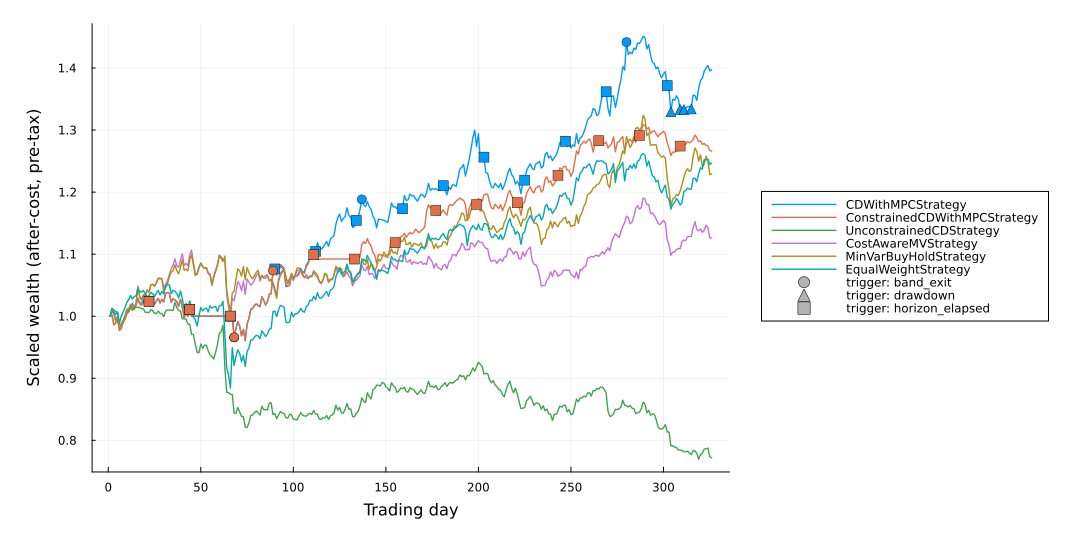

In [5]:
# Wealth curves for the canonical seed, with MPC trigger events overlaid.
# Each curve is scaled so day 1 = 1.0; the y-axis reads as a multiple of starting wealth.
# Trigger markers (only the two MPC strategies have a trigger log):
#   ● circle    — band-exit fire (realized path left the in-spec band)
#   ▲ triangle  — drawdown-circuit-breaker fire (realized drawdown ≥ D_max)
#   ■ square    — horizon-elapsed fire (T trading days since last allocation)
# Marker color matches the line color of the strategy that fired.
p = let
    # Empty Plots.jl canvas: outer-right legend, fixed margins so the wealth
    # lines have room, and explicit x-ticks every 50 trading days so the
    # reader can locate trigger events without counting.
    plt = plot(
        legend = :outerright, size = (1080, 540),
        xlabel = "Trading day",
        ylabel = "Scaled wealth (after-cost, pre-tax)",
        xticks = 0:50:330,                                                         # one tick every 50 trading days (hold-out is 326)
        left_margin   = 10Plots.mm,
        bottom_margin =  8Plots.mm,
        right_margin  =  6Plots.mm,
        top_margin    =  4Plots.mm,
    )

    # ── Step 1: draw one wealth curve per strategy. Capture each line's color
    #            so the trigger markers below can match the line they overlay.
    line_color = Dict{String, Any}()                                              # strategy name → Plots color
    for (name, r) in canonical                                                    # canonical::Dict{String, MyBacktestResult}
        w = r.wealth_after_cost_pretax                                            # length-326 vector: pre-tax wealth at each hold-out day
        plot!(plt, w ./ w[1]; label = name, lw = 1.4)                             # scale so day-1 wealth = 1.0, then add the line
        line_color[name] = plt.series_list[end][:linecolor]                       # remember the auto-assigned color for marker reuse
    end

    # ── Step 2: overlay trigger events. Only the two MPC strategies populate
    #            r.trigger_log; the four non-MPC baselines have an empty log and
    #            are skipped by the `continue` guard.
    reason_shape = (band_exit = :circle, drawdown = :utriangle, horizon_elapsed = :rect)
    for (name, r) in canonical
        isempty(r.trigger_log) && continue                                        # skip non-MPC strategies
        w  = r.wealth_after_cost_pretax                                           # same wealth path used for the line above
        w0 = w[1]                                                                  # day-1 wealth, for consistent marker scaling
        for (reason, shape) in pairs(reason_shape)                                # iterate the 3 trigger reasons
            # Filter to events that fired (t.fired == true) for THIS reason on this strategy.
            evts = filter(t -> t.fired && t.reason === reason, r.trigger_log)
            isempty(evts) && continue                                              # nothing to draw for this (strategy, reason)
            xs = [t.t_global         for t in evts]                                # absolute trading-day index of each fire
            ys = [w[t.t_global] / w0 for t in evts]                                # scaled wealth at the same day
            scatter!(plt, xs, ys;
                label = "",                                                        # no per-strategy legend entry (legend uses stubs below)
                markershape = shape, markersize = 5,
                markercolor = line_color[name],                                    # same color as this strategy's line
                markerstrokewidth = 0.4, markerstrokecolor = :black,
            )
        end
    end

    # ── Step 3: add three off-canvas (NaN, NaN) markers so the trigger-reason
    #            legend entries appear without polluting the chart area.
    #            Plots silently drops NaN coordinates from the chart but still
    #            renders them in the legend.
    for (reason, shape) in pairs(reason_shape)
        scatter!(plt, [NaN], [NaN];
            label = "trigger: " * String(reason),                                 # e.g. "trigger: band_exit"
            markershape = shape, markersize = 5,
            markercolor = :gray70, markerstrokecolor = :black,                     # neutral gray for the legend stub
            markerstrokewidth = 0.4,
        )
    end

    plt                                                                            # return the figure (bound to `p`)
end


### MPC Trigger Reasons

Only the two MPC strategies (CDWithMPC, ConstrainedCDWithMPC) maintain a trigger log. Each fire is tagged with the condition that tripped it (out-of-band, $T$-day refresh, or the drawdown circuit-breaker), so we can see whether re-allocations are driven by realized drift or by the calendar. Counts shown are for the canonical reporting seed.


In [6]:
# For the canonical seed, count how many times each MPC strategy's trigger
# fired under each of the three reasons (:band_exit, :drawdown, :horizon_elapsed).
# Strategies with no trigger log (the four non-MPC baselines) are skipped.
#
# Output line format: <strategy name (left-padded to 35)>  <Dict reason => count>
let
    for (name, r) in canonical                                                    # canonical::Dict{String, MyBacktestResult}
        isempty(r.trigger_log) && continue                                        # skip the four non-MPC baselines
        reasons = [t.reason for t in r.trigger_log if t.fired]                    # only events that actually fired
        isempty(reasons) && continue                                              # MPC strategy with zero fires in this seed (rare)
        counts = Dict(rs => count(==(rs), reasons) for rs in unique(reasons))     # bucket and count each reason
        println(rpad(name, 35), "  ", counts)                                     # left-pad so the Dicts align column-wise
    end
end;


CDWithMPCStrategy                    Dict(:drawdown => 4, :horizon_elapsed => 13, :band_exit => 3)
ConstrainedCDWithMPCStrategy         Dict(:horizon_elapsed => 13, :band_exit => 2)


### Multi-Seed Backtest Distribution

The two MPC strategies depend on the backtest RNG seed through the Monte Carlo paths drawn by the [`forward_project`](https://varnerlab.org/modified_cobb_douglas_example/dev/api/mpc/#ConstrainedCobbDouglas.forward_project) function. To honestly report performance we run each strategy across 20 seeds (2001 through 2020) and report the distribution of outcomes. The four non-MPC strategies (EW, MinVar, UnconstrainedCD, CostAwareMV) are deterministic given prices and collapse to a single value; they are included in the table to keep the row set uniform.


In [7]:
# Multi-seed bake-off distribution. One row per strategy, sorted descending
# by median Sharpe. The four deterministic strategies (EW, MinVar,
# UnconstrainedCD, CostAwareMV) have all 20 seeds collapse to a single
# value, so for them min = med = max and n_uniq_Shp = 1.
#
# Table columns:
#   Strategy      — Julia type name of the allocation strategy
#   Sharpe_min    — minimum annualized Sharpe across the 20 MC seeds
#   Sharpe_med    — median annualized Sharpe across the 20 MC seeds
#   Sharpe_max    — maximum annualized Sharpe across the 20 MC seeds
#   n_uniq_Shp    — count of distinct Sharpe values among the 20 seeds (1 = deterministic)
#   MaxDD_med_pct — median peak-to-trough drawdown across seeds, in percent
#   WT_W0_med     — median ratio of final wealth to starting wealth (W_T / W_0)
#   nTrig_med     — median number of MPC trigger fires over the hold-out (0 for non-MPC)
let
    rows = NamedTuple[]
    # bt_mc["summary"] is Dict{String, Dict{String, Any}}: strategy name → aggregated metrics
    for (name, agg) in bt_mc["summary"]
        sh = agg["sharpe_mc"]                                                     # length-20 Vector{Float64}: per-seed Sharpe
        dd = agg["max_dd_mc"]                                                     # length-20 vector: per-seed max drawdown (fraction)
        wt = agg["W_T_over_W0_mc"]                                                # length-20 vector: per-seed W_T / W_0 (multiple)

        push!(rows, (
            Strategy      = name,
            Sharpe_min    = round(minimum(sh);     digits = 3),                   # worst-case seed Sharpe
            Sharpe_med    = round(median(sh);      digits = 3),                   # 50th-percentile Sharpe
            Sharpe_max    = round(maximum(sh);     digits = 3),                   # best-case seed Sharpe
            n_uniq_Shp    = length(unique(sh)),                                    # how many distinct Sharpe values among 20 seeds
            MaxDD_med_pct = round(median(dd) * 100; digits = 1),                  # fraction → percent
            WT_W0_med     = round(median(wt);      digits = 3),                   # multiple of starting wealth (1.000 = breakeven)
            nTrig_med     = round(Int, median(agg["n_mpc_triggers_mc"])),         # 20-seed median trigger count (integer)
        ))
    end

    sort!(rows; by = r -> -r.Sharpe_med)                                          # best median Sharpe first

    pretty_table(
        DataFrame(rows);
        backend = :text,
        table_format = TextTableFormat(borders = text_table_borders__compact),
        fit_table_in_display_vertically = false,
        fit_table_in_display_horizontally = false,
    )
end;


 ------------------------------ ------------ ------------ ------------ ------------ --------------- ----------- -----------
                      Strategy   Sharpe_min   Sharpe_med   Sharpe_max   n_uniq_Shp   MaxDD_med_pct   WT_W0_med   nTrig_med 
                        String      Float64      Float64      Float64        Int64         Float64     Float64       Int64 
 ------------------------------ ------------ ------------ ------------ ------------ --------------- ----------- -----------
             CDWithMPCStrategy        1.358        2.079        2.079            3             8.4       1.398          20
  ConstrainedCDWithMPCStrategy        1.542        1.681        2.166            7             7.5       1.266          16
         MinVarBuyHoldStrategy        1.199        1.199        1.199            1            11.0       1.229           0
           EqualWeightStrategy         1.16         1.16         1.16            1            15.9       1.247           0
           C

### σ_max Sensitivity Sweep

How sensitive is the constrained-CD design to the covariance budget $\sigma_{\max}$? The sweep in [`scripts/07_sigma_max_sweep.jl`](scripts/07_sigma_max_sweep.jl) answers this directly. We vary $\sigma_{\max}$ over a grid spanning tight values below $\sigma_m$ (constraint binding) to a loose value far above $\sigma_m$ (constraint effectively inactive), while holding the basket, hold-out window, MPC spec, $K_{\text{turnover}}$, $w_{\max}$, cost and tax models, and seed range fixed at their headline-bake-off values. Only $\sigma_{\max}$ on the [`ConstrainedCDWithMPCStrategy`](https://varnerlab.org/modified_cobb_douglas_example/dev/api/allocator/#ConstrainedCobbDouglas.ConstrainedCDWithMPCStrategy) strategy is varied. The other five strategies are $\sigma_{\max}$-invariant; we reference the [`CDWithMPCStrategy`](https://varnerlab.org/modified_cobb_douglas_example/dev/api/allocator/#ConstrainedCobbDouglas.CDWithMPCStrategy) strategy's median Sharpe from the headline bake-off as the no-constraint upper bound.

The cell below loads the artifact at [`scripts/data/sigma_max_sweep.jld2`](scripts/data/sigma_max_sweep.jld2) and prints the per-$\sigma_{\max}$ summary table.


In [9]:
# Load the σ_max sweep artifact at the top level so downstream cells (the
# table here and the plot in the next cell) can both read `sweep`.
_check_artifact(joinpath(_PATH_TO_ARTIFACTS, "sigma_max_sweep.jld2"))
sweep = load_results(joinpath(_PATH_TO_ARTIFACTS, "sigma_max_sweep.jld2"))

# σ_max sweep summary. One row per grid value (sorted ascending).
# Quantiles (Q25 / median / Q75) describe the 20-seed Sharpe distribution at
# each σ_max. Trigger-reason columns are mean fires per seed at that σ_max.
#
# Table columns:
#   σ_max     — covariance budget on the constrained-CD allocator (growth-rate-vol units)
#   Shp_Q25   — 25th percentile of the 20-seed Sharpe distribution
#   Shp_med   — median (50th percentile) Sharpe
#   Shp_Q75   — 75th percentile Sharpe
#   MaxDD_pct — median peak-to-trough drawdown across seeds, in percent
#   Turn_med  — median annualized portfolio turnover across seeds
#   band      — mean number of band-exit trigger fires per seed
#   dd_trig   — mean number of drawdown-circuit-breaker fires per seed
#   horizon   — mean number of T-day-elapsed (calendar) trigger fires per seed
let
    grid = sweep["sigma_max_grid"]                                                # σ_max values swept (ascending)
    rows = NamedTuple[]                                                            # accumulator for per-σ_max table rows

    for σmax in grid                                                               # one iteration per swept σ_max value
        s   = sweep["summary"][σmax]                                               # aggregated metrics at this σ_max
        sh  = s["sharpe_mc"]                                                       # length-20 per-seed Sharpe
        dd  = s["max_dd_mc"]                                                       # length-20 per-seed max drawdown (fraction)
        tn  = s["ann_turnover_mc"]                                                 # length-20 per-seed annualized turnover
        rps = s["trigger_reason_per_seed"]                                         # Dict{String,Float64}: reason → mean fires/seed

        push!(rows, (
            σ_max     = σmax,
            Shp_Q25   = round(quantile(sh, 0.25); digits = 3),                    # bottom-quartile Sharpe (downside seed)
            Shp_med   = round(median(sh);         digits = 3),                    # median (50th percentile) Sharpe
            Shp_Q75   = round(quantile(sh, 0.75); digits = 3),                    # top-quartile Sharpe (upside seed)
            MaxDD_pct = round(median(dd) * 100;   digits = 1),                    # fraction → percent
            Turn_med  = round(median(tn);         digits = 2),                    # multiple of portfolio value, annualized
            band      = round(get(rps, "band_exit",       0.0); digits = 1),      # 0.0 fallback if key missing
            dd_trig   = round(get(rps, "drawdown",        0.0); digits = 1),
            horizon   = round(get(rps, "horizon_elapsed", 0.0); digits = 1),
        ))
    end

    pretty_table(
        DataFrame(rows);
        backend = :text,
        table_format = TextTableFormat(borders = text_table_borders__compact),
        fit_table_in_display_vertically = false,
        fit_table_in_display_horizontally = false,
    )
end;


 --------- --------- --------- --------- ----------- ---------- --------- --------- ---------
    σ_max   Shp_Q25   Shp_med   Shp_Q75   MaxDD_pct   Turn_med      band   dd_trig   horizon 
  Float64   Float64   Float64   Float64     Float64    Float64   Float64   Float64   Float64 
 --------- --------- --------- --------- ----------- ---------- --------- --------- ---------
      1.5     1.848     1.977      1.99         5.3       9.98       4.4       0.0      13.0
      2.0     1.742     1.874     1.909         5.9      12.18       4.2       0.0      13.0
     2.25     1.682     1.814     1.914         6.7      12.87       4.0       0.0      13.0
      2.5     1.679     1.902     2.004         7.5      13.19       3.8       0.0      13.0
     2.75     1.659      1.92     2.006         7.5      13.32       3.8       0.0      13.0
      3.0     1.657     1.927     2.005         7.5      13.34       3.8       0.0      13.0
      3.5     1.657     1.927     2.005         7.5      13.34    

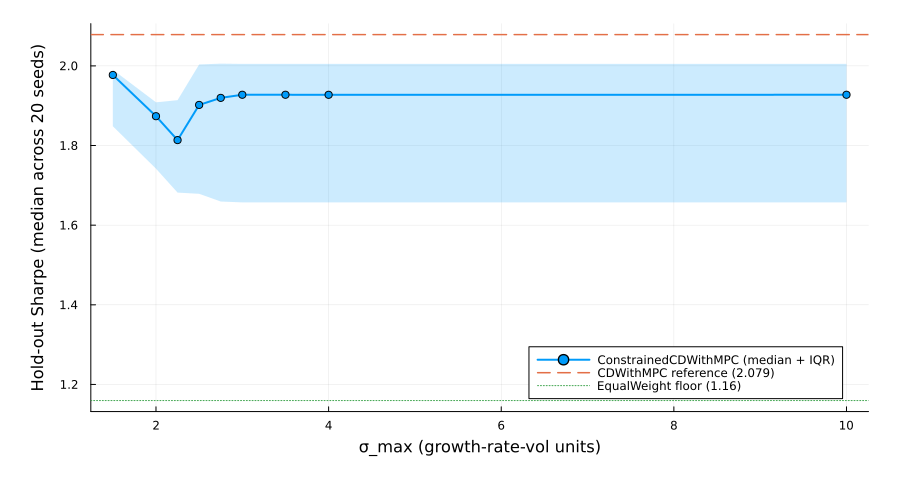

In [10]:
# σ_max sweep: median ± IQR Sharpe ribbon over the grid, with two reference
# horizontal lines from the headline bake-off:
#   CDWithMPC median — no-constraint upper bound (σ_max-invariant, dashed)
#   EqualWeight     — buy-and-hold floor any active strategy must clear (dotted)
p_sigma = let
    grid    = sweep["sigma_max_grid"]                                              # x-axis values (ascending σ_max grid)
    # For each σ_max value, summarize the 20-seed Sharpe distribution into 3 vectors.
    shp_med = [median(sweep["summary"][σ]["sharpe_mc"])         for σ in grid]     # median Sharpe at each σ_max
    shp_q25 = [quantile(sweep["summary"][σ]["sharpe_mc"], 0.25) for σ in grid]     # bottom quartile
    shp_q75 = [quantile(sweep["summary"][σ]["sharpe_mc"], 0.75) for σ in grid]     # top quartile

    # Reference Sharpes from the headline bake-off (both σ_max-invariant).
    cd_mpc_med = median(bt_mc["summary"]["CDWithMPCStrategy"]["sharpe_mc"])        # no-constraint upper bound
    ew_med     = median(bt_mc["summary"]["EqualWeightStrategy"]["sharpe_mc"])       # buy-and-hold floor

    plt = plot(
        size = (900, 480), legend = :bottomright,
        xlabel = "σ_max (growth-rate-vol units)",
        ylabel = "Hold-out Sharpe (median across 20 seeds)",
        left_margin = 10Plots.mm, bottom_margin = 8Plots.mm,
        right_margin = 6Plots.mm, top_margin = 4Plots.mm,
    )
    # Sweep curve: median (solid) with IQR ribbon (light fill).
    # The `ribbon` kwarg takes (lower_offset, upper_offset) measured FROM the
    # median; both must be non-negative, hence the two subtractions.
    plot!(plt, grid, shp_med;
        ribbon = (shp_med .- shp_q25, shp_q75 .- shp_med),
        fillalpha = 0.20, lw = 2, marker = :circle,
        label = "ConstrainedCDWithMPC (median + IQR)",
    )
    # Reference: best allocator in the bake-off (dashed horizontal line).
    hline!(plt, [cd_mpc_med]; lw = 1.5, ls = :dash,
        label = "CDWithMPC reference ($(round(cd_mpc_med; digits = 3)))",
    )
    # Reference: buy-and-hold floor (dotted horizontal line).
    hline!(plt, [ew_med]; lw = 1.0, ls = :dot,
        label = "EqualWeight floor ($(round(ew_med; digits = 3)))",
    )
    plt
end


### w_max Sensitivity Sweep

The second sweep, in [`scripts/08_w_max_sweep.jl`](scripts/08_w_max_sweep.jl), varies the per-name concentration cap $w_{\max}$ while pinning $\sigma_{\max}$ at a loose value (covariance constraint inactive) and $K_{\text{turnover}}$ at the headline-bake-off default. The grid spans tight concentration caps (every name forced toward a near-equal-weight allocation) up to $w_{\max} = 1$ (concentration cap effectively inactive). At the upper end of the grid all three client-facing constraints are off, so the [`ConstrainedCDWithMPCStrategy`](https://varnerlab.org/modified_cobb_douglas_example/dev/api/allocator/#ConstrainedCobbDouglas.ConstrainedCDWithMPCStrategy) strategy should asymptote to the [`CDWithMPCStrategy`](https://varnerlab.org/modified_cobb_douglas_example/dev/api/allocator/#ConstrainedCobbDouglas.CDWithMPCStrategy) strategy's closed-form behavior; this is the sanity-check end of the grid.

The cell below loads the artifact at [`scripts/data/w_max_sweep.jld2`](scripts/data/w_max_sweep.jld2) and prints the per-$w_{\max}$ summary table.


In [11]:
# Load the w_max sweep artifact at top level so both the table cell here and
# the plot cell below can read `wsweep` without rerunning the load.
_check_artifact(joinpath(_PATH_TO_ARTIFACTS, "w_max_sweep.jld2"))
wsweep = load_results(joinpath(_PATH_TO_ARTIFACTS, "w_max_sweep.jld2"))

# w_max sweep summary. One row per grid value (sorted ascending). Quantiles
# describe the 20-seed Sharpe distribution at each w_max. Trigger-reason
# columns are mean fires per seed.
#
# Table columns:
#   w_max     — per-name concentration cap on the constrained-CD allocator (fraction of B)
#   Shp_Q25   — 25th percentile of the 20-seed Sharpe distribution
#   Shp_med   — median Sharpe
#   Shp_Q75   — 75th percentile Sharpe
#   MaxDD_pct — median peak-to-trough drawdown across seeds, in percent
#   Turn_med  — median annualized portfolio turnover across seeds
#   band      — mean number of band-exit trigger fires per seed
#   dd_trig   — mean number of drawdown-circuit-breaker fires per seed
#   horizon   — mean number of T-day-elapsed (calendar) trigger fires per seed
let
    grid = wsweep["w_max_grid"]                                                    # w_max values swept (ascending)
    rows = NamedTuple[]                                                             # accumulator for per-w_max table rows

    for wmax in grid                                                                # one iteration per swept w_max value
        s   = wsweep["summary"][wmax]                                               # aggregated metrics at this w_max
        sh  = s["sharpe_mc"]                                                        # length-20 per-seed Sharpe
        dd  = s["max_dd_mc"]                                                        # length-20 per-seed max drawdown (fraction)
        tn  = s["ann_turnover_mc"]                                                  # length-20 per-seed annualized turnover
        rps = s["trigger_reason_per_seed"]                                          # Dict reason → mean fires/seed

        push!(rows, (
            w_max     = wmax,
            Shp_Q25   = round(quantile(sh, 0.25); digits = 3),                     # bottom-quartile Sharpe
            Shp_med   = round(median(sh);         digits = 3),                     # median Sharpe
            Shp_Q75   = round(quantile(sh, 0.75); digits = 3),                     # top-quartile Sharpe
            MaxDD_pct = round(median(dd) * 100;   digits = 1),                     # fraction → percent
            Turn_med  = round(median(tn);         digits = 2),                     # multiple of portfolio, annualized
            band      = round(get(rps, "band_exit",       0.0); digits = 1),       # 0.0 fallback if key missing
            dd_trig   = round(get(rps, "drawdown",        0.0); digits = 1),
            horizon   = round(get(rps, "horizon_elapsed", 0.0); digits = 1),
        ))
    end

    pretty_table(
        DataFrame(rows);
        backend = :text,
        table_format = TextTableFormat(borders = text_table_borders__compact),
        fit_table_in_display_vertically = false,
        fit_table_in_display_horizontally = false,
    )
end;


 --------- --------- --------- --------- ----------- ---------- --------- --------- ---------
    w_max   Shp_Q25   Shp_med   Shp_Q75   MaxDD_pct   Turn_med      band   dd_trig   horizon 
  Float64   Float64   Float64   Float64     Float64    Float64   Float64   Float64   Float64 
 --------- --------- --------- --------- ----------- ---------- --------- --------- ---------
      0.1     1.059     1.432     1.733         7.5      12.07       3.8       0.0      13.6
     0.15     1.166     1.493     1.533         7.5       11.5       3.6       0.0      13.8
      0.2     1.657     1.927     2.005         7.5      13.34       3.8       0.0      13.0
      0.3     1.528     1.548     1.656         8.1      14.08       3.2       1.6      12.7
      0.4     1.434     1.434     1.434         9.8      24.04       2.8      12.8      12.2
      0.5     0.698     0.852     1.474        13.7      26.56       3.4      20.6      11.1
      0.7     2.079     2.079     2.079         8.4      19.06    

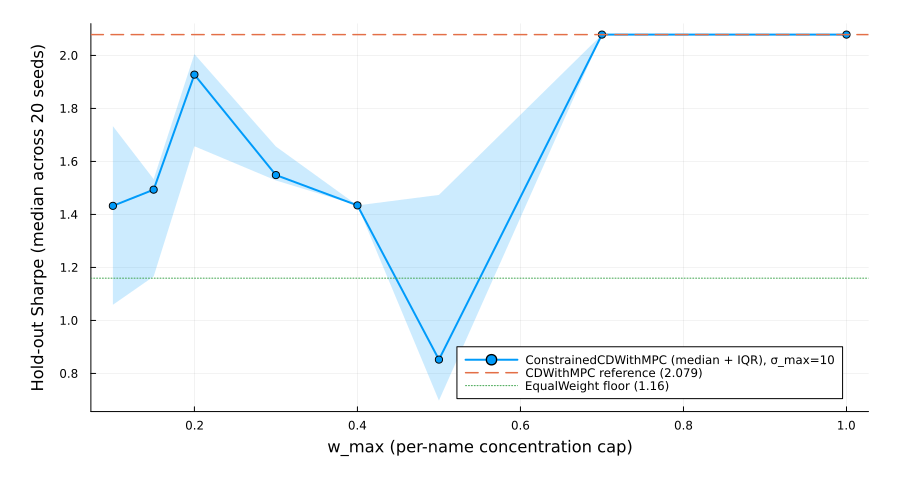

In [12]:
# w_max sweep: median ± IQR Sharpe ribbon over the grid, with the same two
# headline-bake-off reference lines used in the σ_max plot.
p_wmax = let
    grid    = wsweep["w_max_grid"]                                                  # x-axis values (ascending w_max grid)
    shp_med = [median(wsweep["summary"][w]["sharpe_mc"])         for w in grid]     # median Sharpe at each w_max
    shp_q25 = [quantile(wsweep["summary"][w]["sharpe_mc"], 0.25) for w in grid]     # bottom quartile
    shp_q75 = [quantile(wsweep["summary"][w]["sharpe_mc"], 0.75) for w in grid]     # top quartile

    # Reference Sharpes from the headline bake-off (both w_max-invariant).
    cd_mpc_med = median(bt_mc["summary"]["CDWithMPCStrategy"]["sharpe_mc"])         # no-constraint upper bound
    ew_med     = median(bt_mc["summary"]["EqualWeightStrategy"]["sharpe_mc"])        # buy-and-hold floor

    plt = plot(
        size = (900, 480), legend = :bottomright,
        xlabel = "w_max (per-name concentration cap)",
        ylabel = "Hold-out Sharpe (median across 20 seeds)",
        left_margin = 10Plots.mm, bottom_margin = 8Plots.mm,
        right_margin = 6Plots.mm, top_margin = 4Plots.mm,
    )
    # Sweep curve: median with IQR ribbon (lower/upper offsets from the median).
    plot!(plt, grid, shp_med;
        ribbon = (shp_med .- shp_q25, shp_q75 .- shp_med),
        fillalpha = 0.20, lw = 2, marker = :circle,
        label = "ConstrainedCDWithMPC (median + IQR), σ_max=10",
    )
    # Reference: best allocator (dashed).
    hline!(plt, [cd_mpc_med]; lw = 1.5, ls = :dash,
        label = "CDWithMPC reference ($(round(cd_mpc_med; digits = 3)))",
    )
    # Reference: buy-and-hold floor (dotted).
    hline!(plt, [ew_med]; lw = 1.0, ls = :dot,
        label = "EqualWeight floor ($(round(ew_med; digits = 3)))",
    )
    plt
end


### K_turnover Sensitivity Sweep

The third sweep, in [`scripts/09_k_turnover_sweep.jl`](scripts/09_k_turnover_sweep.jl), varies the per-decision turnover budget $K_{\text{turnover}}$. We pin $\sigma_{\max}$ at a loose value (covariance constraint inactive) and $w_{\max}$ at a tight value, then sweep $K_{\text{turnover}}$ over a grid chosen to straddle the regime where the constraint actually binds at this basket size and budget. The enforced constraint is $\bar{c}\,\|\mathbf{n} - \mathbf{n}_{\text{prev}}\|_1 \le K_{\text{turnover}}$, with $\bar{c}$ supplied by the cost model.

Two regimes are visible in the table. At the tight end the constraint enters the optimization and tightens Sharpe, drawdown, and realized turnover. At the loose end the solver detects that the constraint cannot bind at this budget and basket size and skips it entirely, so those rows collapse to a single identical outcome.

The cell below loads the artifact at [`scripts/data/k_turnover_sweep.jld2`](scripts/data/k_turnover_sweep.jld2) and prints the per-$K_{\text{turnover}}$ summary table.


In [13]:
# Load the K_turnover sweep artifact at top level so both the table cell here
# and the plot cell below can read `ksweep` without rerunning the load.
_check_artifact(joinpath(_PATH_TO_ARTIFACTS, "k_turnover_sweep.jld2"))
ksweep = load_results(joinpath(_PATH_TO_ARTIFACTS, "k_turnover_sweep.jld2"))

# K_turnover sweep summary. One row per grid value (sorted ascending).
# Quantiles describe the 20-seed Sharpe distribution at each K_turnover.
# Trigger-reason columns are mean fires per seed.
#
# Table columns:
#   K_turnover — per-decision turnover budget on the constrained-CD allocator (USD)
#   x_B0       — K_turnover expressed as a multiple of starting budget B_0 = $100,000
#   Shp_Q25    — 25th percentile of the 20-seed Sharpe distribution
#   Shp_med    — median Sharpe
#   Shp_Q75    — 75th percentile Sharpe
#   MaxDD_pct  — median peak-to-trough drawdown across seeds, in percent
#   Turn_med   — median annualized portfolio turnover across seeds
#   band       — mean number of band-exit trigger fires per seed
#   dd_trig    — mean number of drawdown-circuit-breaker fires per seed
#   horizon    — mean number of T-day-elapsed (calendar) trigger fires per seed
let
    grid = ksweep["k_turnover_grid"]                                                # K_turnover values swept (ascending USD)
    B0   = ksweep["config"]["B_0"]                                                  # starting budget the sweep was run under ($100,000)
    rows = NamedTuple[]                                                              # accumulator for per-K_turnover table rows

    for kt in grid                                                                   # one iteration per swept K_turnover value
        s   = ksweep["summary"][kt]                                                  # aggregated metrics at this K_turnover
        sh  = s["sharpe_mc"]                                                         # length-20 per-seed Sharpe
        dd  = s["max_dd_mc"]                                                         # length-20 per-seed max drawdown (fraction)
        tn  = s["ann_turnover_mc"]                                                   # length-20 per-seed annualized turnover
        rps = s["trigger_reason_per_seed"]                                           # Dict reason → mean fires/seed

        push!(rows, (
            K_turnover = round(Int, kt),                                             # integer dollars for clean display
            x_B0       = round(kt / B0; digits = 5),                                 # 5 dp resolves the smallest grid value (0.0001)
            Shp_Q25    = round(quantile(sh, 0.25); digits = 3),                      # bottom-quartile Sharpe
            Shp_med    = round(median(sh);         digits = 3),                      # median Sharpe
            Shp_Q75    = round(quantile(sh, 0.75); digits = 3),                      # top-quartile Sharpe
            MaxDD_pct  = round(median(dd) * 100;   digits = 1),                      # fraction → percent
            Turn_med   = round(median(tn);         digits = 2),                      # multiple of portfolio, annualized
            band       = round(get(rps, "band_exit",       0.0); digits = 1),        # 0.0 fallback if key missing
            dd_trig    = round(get(rps, "drawdown",        0.0); digits = 1),
            horizon    = round(get(rps, "horizon_elapsed", 0.0); digits = 1),
        ))
    end

    pretty_table(
        DataFrame(rows);
        backend = :text,
        table_format = TextTableFormat(borders = text_table_borders__compact),
        fit_table_in_display_vertically = false,
        fit_table_in_display_horizontally = false,
    )
end;


 ------------ --------- --------- --------- --------- ----------- ---------- --------- --------- ---------
  K_turnover      x_B0   Shp_Q25   Shp_med   Shp_Q75   MaxDD_pct   Turn_med      band   dd_trig   horizon 
       Int64   Float64   Float64   Float64   Float64     Float64    Float64   Float64   Float64   Float64 
 ------------ --------- --------- --------- --------- ----------- ---------- --------- --------- ---------
          10    0.0001     1.588     1.588     1.602         3.4        4.4       2.6       0.0      13.2
          25   0.00025      1.66     1.751     1.967         5.2       9.17       3.3       0.0      13.6
          50    0.0005     1.634     1.712     1.809         5.8      11.18       3.5       0.0      13.8
         100     0.001     1.166     1.493     1.533         7.5       11.5       3.6       0.0      13.8
         200     0.002     1.166     1.493     1.533         7.5       11.5       3.6       0.0      13.8
         500     0.005     1.166     1.493

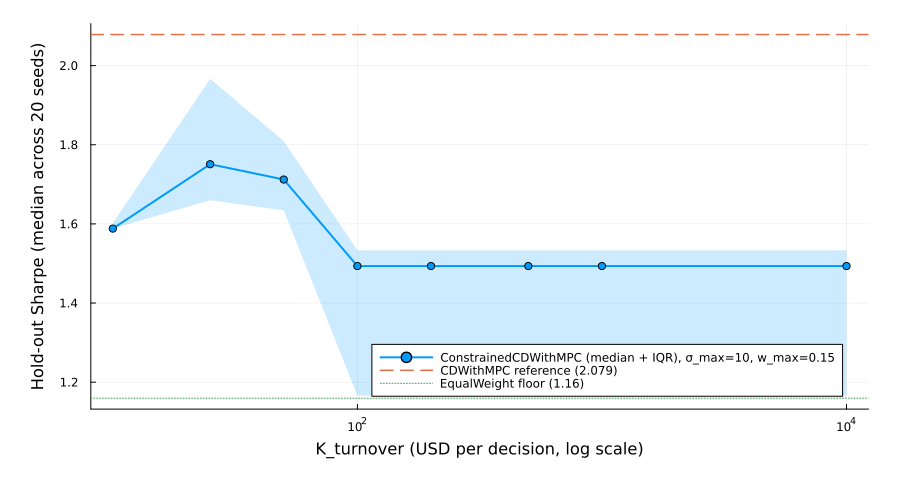

In [14]:
# K_turnover sweep: median ± IQR Sharpe ribbon over the grid on a log-scale
# x-axis (the grid spans 3 decades: $10 → $10,000). Same two headline-bake-off
# reference lines as the other sweep plots.
p_kturn = let
    grid    = ksweep["k_turnover_grid"]                                              # x-axis values (USD, ascending)
    shp_med = [median(ksweep["summary"][k]["sharpe_mc"])         for k in grid]      # median Sharpe at each K_turnover
    shp_q25 = [quantile(ksweep["summary"][k]["sharpe_mc"], 0.25) for k in grid]      # bottom quartile
    shp_q75 = [quantile(ksweep["summary"][k]["sharpe_mc"], 0.75) for k in grid]      # top quartile

    # Reference Sharpes from the headline bake-off (both K_turnover-invariant).
    cd_mpc_med = median(bt_mc["summary"]["CDWithMPCStrategy"]["sharpe_mc"])          # no-constraint upper bound
    ew_med     = median(bt_mc["summary"]["EqualWeightStrategy"]["sharpe_mc"])         # buy-and-hold floor

    plt = plot(
        size = (900, 480), legend = :bottomright,
        xscale = :log10,                                                              # 3-decade x-range needs log scale
        xlabel = "K_turnover (USD per decision, log scale)",
        ylabel = "Hold-out Sharpe (median across 20 seeds)",
        left_margin = 10Plots.mm, bottom_margin = 8Plots.mm,
        right_margin = 6Plots.mm, top_margin = 4Plots.mm,
    )
    # Sweep curve: median with IQR ribbon.
    plot!(plt, grid, shp_med;
        ribbon = (shp_med .- shp_q25, shp_q75 .- shp_med),
        fillalpha = 0.20, lw = 2, marker = :circle,
        label = "ConstrainedCDWithMPC (median + IQR), σ_max=10, w_max=0.15",
    )
    # Reference: best allocator (dashed).
    hline!(plt, [cd_mpc_med]; lw = 1.5, ls = :dash,
        label = "CDWithMPC reference ($(round(cd_mpc_med; digits = 3)))",
    )
    # Reference: buy-and-hold floor (dotted).
    hline!(plt, [ew_med]; lw = 1.0, ls = :dot,
        label = "EqualWeight floor ($(round(ew_med; digits = 3)))",
    )
    plt
end


### cash_revisit_interval Sensitivity Sweep

The fourth sweep, in [`scripts/10_cash_revisit_sweep.jl`](scripts/10_cash_revisit_sweep.jl), varies the new cash-revisit interval knob on the MPC trigger. The T-day horizon discipline is designed to protect a *held* portfolio from churn on SIM/EWLS noise; once the allocator returns the $\varepsilon$-pin defensive regime, there is no held portfolio to protect. The cash-revisit interval lets the strategy re-evaluate the defensive regime on a faster cadence than T. We pin $\sigma_{\max}$ at a loose value (covariance constraint inactive), $w_{\max}$ at the headline-bake-off default, and $K_{\text{turnover}}$ at the headline-bake-off default, then sweep the interval over a grid from sub-T re-evaluation to the T-day default. Setting the interval equal to T reproduces the original cadence (the cash-revisit fire races horizon-elapsed and wins on label only); shorter intervals let the strategy re-enter the market sooner after a defensive fire.

The response surface is bimodal and highly non-monotonic on this hold-out. One sub-T interval produces the best result on every metric (Sharpe, drawdown, turnover, drawdown-circuit-breaker count), but a band of mid-range sub-T intervals is catastrophic: the strategy exits cash during the bad regime, runs into a perpetual drawdown loop, and books on the order of one drawdown-circuit-breaker fire every two to three trading days. The T-day default sits comfortably away from the catastrophe zone but leaves the sweet-spot improvement on the table. The bimodal shape is a robustness warning; before changing the default, this sweep should be cross-validated on out-of-sample baskets or rolling windows.

The cell below loads the artifact at [`scripts/data/cash_revisit_sweep.jld2`](scripts/data/cash_revisit_sweep.jld2) and prints the per-interval summary table.


In [15]:
# Load the cash_revisit sweep artifact at top level so both the table cell
# here and the plot cell below can read `crsweep` without rerunning the load.
_check_artifact(joinpath(_PATH_TO_ARTIFACTS, "cash_revisit_sweep.jld2"))
crsweep = load_results(joinpath(_PATH_TO_ARTIFACTS, "cash_revisit_sweep.jld2"))

# cash_revisit_interval sweep summary. One row per grid value (sorted ascending).
# Quantiles describe the 20-seed Sharpe distribution at each interval.
# Trigger-reason columns are mean fires per seed; the new `cash` column
# reports mean :cash_revisit fires per seed.
#
# Table columns:
#   interval   — cash_revisit_interval in trading days (gates the defensive-cash re-evaluation cadence)
#   Shp_Q25    — 25th percentile of the 20-seed Sharpe distribution
#   Shp_med    — median Sharpe
#   Shp_Q75    — 75th percentile Sharpe
#   MaxDD_pct  — median peak-to-trough drawdown across seeds, in percent
#   Turn_med   — median annualized portfolio turnover across seeds
#   band       — mean number of band-exit trigger fires per seed
#   dd_trig    — mean number of drawdown-circuit-breaker fires per seed
#   horizon    — mean number of T-day-elapsed (calendar) trigger fires per seed
#   cash       — mean number of cash-revisit trigger fires per seed
let
    grid = crsweep["cash_revisit_grid"]                                            # interval values swept (ascending days)
    rows = NamedTuple[]                                                             # accumulator for per-interval table rows

    for interval in grid                                                            # one iteration per swept interval value
        s   = crsweep["summary"][interval]                                          # aggregated metrics at this interval
        sh  = s["sharpe_mc"]                                                        # length-20 per-seed Sharpe
        dd  = s["max_dd_mc"]                                                        # length-20 per-seed max drawdown (fraction)
        tn  = s["ann_turnover_mc"]                                                  # length-20 per-seed annualized turnover
        rps = s["trigger_reason_per_seed"]                                          # Dict reason → mean fires/seed

        push!(rows, (
            interval  = interval,
            Shp_Q25   = round(quantile(sh, 0.25); digits = 3),                     # bottom-quartile Sharpe
            Shp_med   = round(median(sh);         digits = 3),                     # median Sharpe
            Shp_Q75   = round(quantile(sh, 0.75); digits = 3),                     # top-quartile Sharpe
            MaxDD_pct = round(median(dd) * 100;   digits = 1),                     # fraction → percent
            Turn_med  = round(median(tn);         digits = 2),                     # multiple of portfolio, annualized
            band      = round(get(rps, "band_exit",       0.0); digits = 1),       # 0.0 fallback if key missing
            dd_trig   = round(get(rps, "drawdown",        0.0); digits = 1),
            horizon   = round(get(rps, "horizon_elapsed", 0.0); digits = 1),
            cash      = round(get(rps, "cash_revisit",    0.0); digits = 1),
        ))
    end

    pretty_table(
        DataFrame(rows);
        backend = :text,
        table_format = TextTableFormat(borders = text_table_borders__compact),
        fit_table_in_display_vertically = false,
        fit_table_in_display_horizontally = false,
    )
end;


 ---------- --------- --------- --------- ----------- ---------- --------- --------- --------- ---------
  interval   Shp_Q25   Shp_med   Shp_Q75   MaxDD_pct   Turn_med      band   dd_trig   horizon      cash 
     Int64   Float64   Float64   Float64     Float64    Float64   Float64   Float64   Float64   Float64 
 ---------- --------- --------- --------- ----------- ---------- --------- --------- --------- ---------
         1     0.461     0.827     0.966        16.0      24.61       2.6      25.8      10.4       2.8
         3     0.624     0.759     0.759        16.1      22.46       0.3      31.0       9.7       1.3
         5     2.302     2.302      2.37         5.9       7.71       1.6       0.0      13.0       3.0
         7    -0.628    -0.628    -0.628        18.8      74.65       2.0     132.0       2.0       1.0
        10    -0.632    -0.632    -0.632        18.8      73.66       0.0     132.0       2.0       1.0
        14    -0.569    -0.569    -0.569        17.9      73

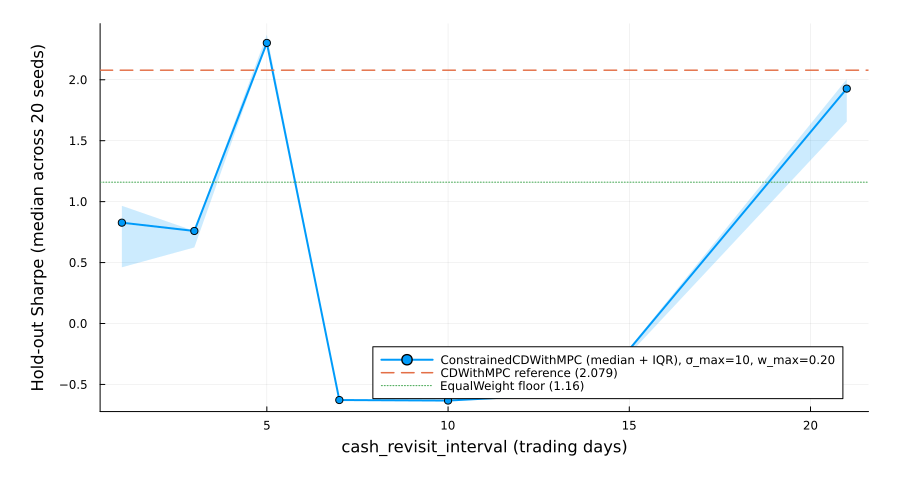

In [16]:
# cash_revisit_interval sweep: median ± IQR Sharpe ribbon over the grid,
# with the same two headline-bake-off reference lines used in the other sweeps.
# The grid is small (7 points) and the response is highly non-monotonic, so
# the line connects discrete dots rather than describing a smooth curve.
p_crint = let
    grid    = crsweep["cash_revisit_grid"]                                          # x-axis values (interval, ascending days)
    shp_med = [median(crsweep["summary"][k]["sharpe_mc"])         for k in grid]    # median Sharpe at each interval
    shp_q25 = [quantile(crsweep["summary"][k]["sharpe_mc"], 0.25) for k in grid]    # bottom quartile
    shp_q75 = [quantile(crsweep["summary"][k]["sharpe_mc"], 0.75) for k in grid]    # top quartile

    # Reference Sharpes from the headline bake-off (both interval-invariant).
    cd_mpc_med = median(bt_mc["summary"]["CDWithMPCStrategy"]["sharpe_mc"])         # no-constraint upper bound
    ew_med     = median(bt_mc["summary"]["EqualWeightStrategy"]["sharpe_mc"])        # buy-and-hold floor

    plt = plot(
        size = (900, 480), legend = :bottomright,
        xlabel = "cash_revisit_interval (trading days)",
        ylabel = "Hold-out Sharpe (median across 20 seeds)",
        left_margin = 10Plots.mm, bottom_margin = 8Plots.mm,
        right_margin = 6Plots.mm, top_margin = 4Plots.mm,
    )
    # Sweep curve: median with IQR ribbon.
    plot!(plt, grid, shp_med;
        ribbon = (shp_med .- shp_q25, shp_q75 .- shp_med),
        fillalpha = 0.20, lw = 2, marker = :circle,
        label = "ConstrainedCDWithMPC (median + IQR), σ_max=10, w_max=0.20",
    )
    # Reference: best allocator (dashed).
    hline!(plt, [cd_mpc_med]; lw = 1.5, ls = :dash,
        label = "CDWithMPC reference ($(round(cd_mpc_med; digits = 3)))",
    )
    # Reference: buy-and-hold floor (dotted).
    hline!(plt, [ew_med]; lw = 1.0, ls = :dot,
        label = "EqualWeight floor ($(round(ew_med; digits = 3)))",
    )
    plt
end


___
## Summary

This notebook benchmarked a constrained Cobb-Douglas allocator with MPC trigger discipline against five baseline strategies on a forward hold-out window, then swept each client-facing constraint and the MPC trigger configuration to map sensitivity.

> **Key Takeaways:**
> 
> * **Cadence is the load-bearing fix:** Replacing a fixed-cadence rebalance with an event-driven trigger is the largest single design lever in the comparison, capable of moving the same allocator from the bottom of the ranking to the top. The trigger discipline (forward-project, refresh on band exit, calendar elapse, or drawdown breach) is what addresses the live engine's flat-with-bleed failure mode; every other design choice is layered on top.
> 
> * **The constraint layer trades Sharpe for drawdown control:** Adding covariance, turnover, and concentration constraints costs a fraction of a Sharpe unit relative to the unconstrained-MPC variant, but buys a tighter max-drawdown and a far steadier trigger profile (zero drawdown-circuit-breaker fires under the constrained variant versus several under the unconstrained-MPC variant). The constraint-versus-no-constraint choice is not a free lunch, but it is not net-negative either.
> 
> * **Read distributions, not single trials:** When a strategy is stochastic in its forward-projection Monte Carlo paths, the honest summary statistic is the median across seeds, and any single seed misrepresents the strategy's behavior. Deterministic baselines collapse to a single point per metric, which is directly comparable to the Monte Carlo median rather than to any individual seed.

Cadence discipline (the MPC trigger) is the structural fix to the live engine's failure mode, with the constraint layer as a tunable risk-control overlay on top.

### Disclaimer

This content is for educational purposes only and does not constitute investment advice. The examples use real historical data, a frozen SIM calibration on 2014-2024, and a single 2025-2026 forward window; conclusions about cost-aware constrained allocation and MPC trigger discipline do not generalize to other markets, time periods, or client risk profiles without re-calibration.

___
